In [1]:
import nibabel as nib 
import os 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
from skimage.metrics import mean_squared_error as mse
from scipy.spatial.distance import jensenshannon
import pandas as pd
from tqdm import tqdm
from math import log10
from scipy.stats import entropy
from scipy.interpolate import make_interp_spline
from scipy.stats import rankdata
from scipy.stats import wilcoxon, ranksums, mannwhitneyu

In [2]:
def kl_div(dist1, dist2):
    dist1_hist, dist1_bins = np.histogram(dist1, bins = 10, density = True)
    dist2_hist, dist2_bins = np.histogram(dist2, bins = 10, density = True)
    
    kl = entropy(dist1_hist, dist2_hist)
    return kl

In [ ]:
mse_b50ftob30f_scores = {}
mse_b80ftob30f_scores = {}
mse_bonetostd_scores = {}
mse_lungtostd_scores = {}
kl_bonetob30f_scores = {}
kl_lungtob30f_scores = {}
kl_stdtob30f_scores = {}

b50f = pd.read_csv("path/to/B50f_masked_emphysema/emph.csv")
b50f =  b50f.sort_values(by='pid')
b30f_b50f = pd.read_csv("/B30f_B50f/B30f_masked_emphysema/emph.csv")
b30f_b50f = b30f_b50f.sort_values(by='pid')
b80f = pd.read_csv("/B30f_B80f/B80f_masked_emphysema/emph.csv")
b80f = b80f.sort_values(by='pid')
b30f_b80f = pd.read_csv("/B30f_B80f/B30f_masked_emphysema/emph.csv")
b30f_b80f = b30f_b80f.sort_values(by='pid')
bone = pd.read_csv("/STANDARD_BONE/BONE_emphysema/emph.csv")
bone = bone.sort_values(by='pid')
std_bone = pd.read_csv("/STANDARD_BONE/STANDARD_emphysema/emph.csv")
std_bone = std_bone.sort_values(by='pid')
lung = pd.read_csv("/STANDARD_LUNG/LUNG_emphysema/emph.csv")
lung = lung.sort_values(by='pid')
std_lung = pd.read_csv("/STANDARD_LUNG/STANDARD_emphysema/emph.csv")
std_lung = std_lung.sort_values(by='pid') 

In [ ]:
for i in tqdm(range(2,202,2)):
    b50ftob30f = pd.read_csv(f"/B50ftoB30f_emphysema/epoch_{i}/emph.csv")
    b50ftob30f = b50ftob30f.sort_values(by='pid')
    b80ftob30f = pd.read_csv(f"/B80ftoB30f_emphysema/epoch_{i}/emph.csv")
    b80ftob30f = b80ftob30f.sort_values(by='pid')
    bonetostd = pd.read_csv(f"/BONEtoSTANDARD_emphysema/epoch_{i}/emph.csv")
    bonetostd = bonetostd.sort_values(by='pid')
    lungtostd = pd.read_csv(f"/LUNGtoSTANDARD_emphysema/epoch_{i}/emph.csv")
    lungtostd = lungtostd.sort_values(by='pid')
    bonetob30f = pd.read_csv(f"/BONEtoB30f_emphysema/epoch_{i}/emph.csv")
    bonetob30f = bonetob30f.sort_values(by='pid')
    lungtob30f = pd.read_csv(f"/LUNGtoB30f_emphysema/epoch_{i}/emph.csv")
    lungtob30f = lungtob30f.sort_values(by='pid')
    stdtob30f = pd.read_csv(f"/STANDARDtoB30f_emphysema/epoch_{i}/emph.csv") #Used the STANDARD from BONE_STANDARD pair.
    stdtob30f = stdtob30f.sort_values(by='pid')

    mse_b50ftob30f_scores[i] = np.sqrt(mse(b50ftob30f['emph_score'].values, b30f_b50f['emph_score'].values))
    mse_b80ftob30f_scores[i] = np.sqrt(mse(b80ftob30f['emph_score'].values, b30f_b80f['emph_score'].values))
    mse_bonetostd_scores[i] = np.sqrt(mse(bonetostd['emph_score'].values, std_bone['emph_score'].values))
    mse_lungtostd_scores[i] = np.sqrt(mse(lungtostd['emph_score'].values, std_lung['emph_score'].values))
    # mse_b50ftob30f_scores[i] = mse(b50ftob30f['emph_score'].values, b30f_b50f['emph_score'].values)
    # mse_b80ftob30f_scores[i] = mse(b80ftob30f['emph_score'].values, b30f_b80f['emph_score'].values)
    # mse_bonetostd_scores[i] = mse(bonetostd['emph_score'].values, std_bone['emph_score'].values)
    # mse_lungtostd_scores[i] = mse(lungtostd['emph_score'].values, std_lung['emph_score'].values)
    kl_bonetob30f_scores[i] = kl_div(bonetob30f['emph_score'].values, b30f_b50f['emph_score'].values)
    kl_lungtob30f_scores[i] = kl_div(lungtob30f['emph_score'].values, b30f_b50f['emph_score'].values)
    kl_stdtob30f_scores[i] = kl_div(stdtob30f['emph_score'].values, b30f_b50f['emph_score'].values)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:02<00:00, 41.44it/s]


In [5]:
# #Check which image is correupted in lungtob30f
# path = "/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation/LUNGtoB30f/epoch_114"

# for file in os.listdir(path):
#    try:
#     print("Load file:", file)
#     img = nib.load(os.path.join(path, file))
#     img = img.get_fdata()
#    except Exception as e:
#        print("Error loading file:", file)
#        print(e)

In [6]:
kl_bonetob30f_scores

{2: 0.3798979735403367,
 4: 0.13646982525359677,
 6: 0.12096198076353122,
 8: 0.1329565682715988,
 10: 0.15386185998647867,
 12: 0.09930829181886851,
 14: 0.10906838946074665,
 16: 0.11075563621317148,
 18: 0.11323979833189095,
 20: 0.10938880354067904,
 22: 0.17396929209620887,
 24: 0.1047343027745186,
 26: 0.20344229908161338,
 28: 0.2822513210798406,
 30: 0.10471760630411471,
 32: 0.09480397380262197,
 34: 0.09492452710202878,
 36: 0.13555910169074362,
 38: 0.2297210493833706,
 40: 0.13015810295592234,
 42: 0.14048846731371625,
 44: 0.12919287720274736,
 46: 0.12096804172382587,
 48: 0.1053041687579249,
 50: 0.09403137539100613,
 52: 0.1128542635223206,
 54: 0.13952616825304442,
 56: 0.1853070198302954,
 58: 0.11273673417288627,
 60: 0.11310770577684205,
 62: 0.12102252279275981,
 64: 0.25079487561856173,
 66: 0.39337932036652007,
 68: 0.1964242235039377,
 70: 0.14031282531662234,
 72: 0.1468078023973895,
 74: 0.13971013465506918,
 76: 0.09045667941593051,
 78: 0.1301581029559223,
 

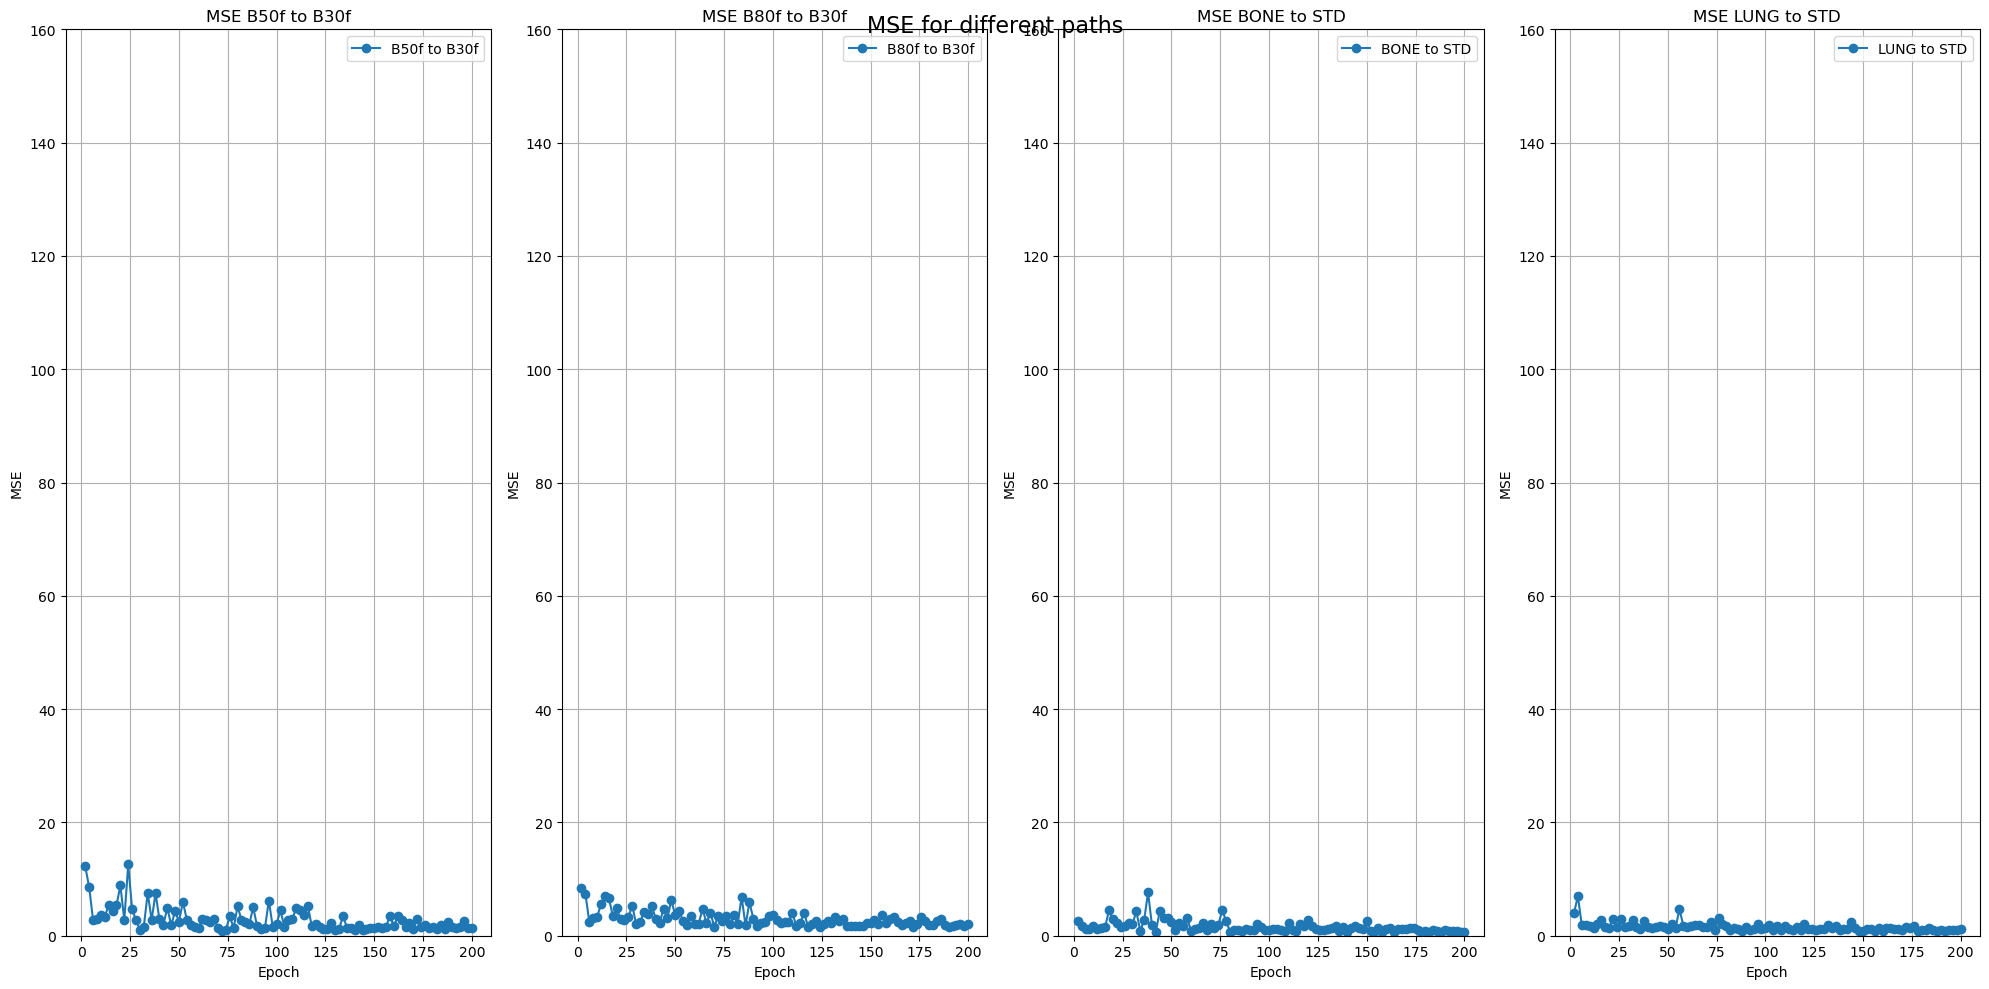

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 10))
axes[0].plot(list(mse_b50ftob30f_scores.keys()), list(mse_b50ftob30f_scores.values()), marker='o', label='B50f to B30f')
axes[0].set_title('MSE B50f to B30f')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_ylim(0, 160)
# axes[0].set_ylim(0, 20)
axes[0].legend()
axes[0].grid()

axes[1].plot(list(mse_b80ftob30f_scores.keys()), list(mse_b80ftob30f_scores.values()), marker='o', label='B80f to B30f')
axes[1].set_title('MSE B80f to B30f')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].set_ylim(0, 160)
# axes[1].set_ylim(0, 20)
axes[1].legend()
axes[1].grid()

axes[2].plot(list(mse_bonetostd_scores.keys()), list(mse_bonetostd_scores.values()), marker='o', label='BONE to STD')
axes[2].set_title('MSE BONE to STD')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE')
axes[2].set_ylim(0, 160)
# axes[2].set_ylim(0, 20)
axes[2].legend()
axes[2].grid()  

axes[3].plot(list(mse_lungtostd_scores.keys()), list(mse_lungtostd_scores.values()), marker='o', label='LUNG to STD')
axes[3].set_title('MSE LUNG to STD')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('MSE')
axes[3].set_ylim(0, 160)
# axes[3].set_ylim(0, 20)
axes[3].legend()
axes[3].grid()
plt.tight_layout()
fig.suptitle('MSE for different paths', fontsize=16)
plt.show()

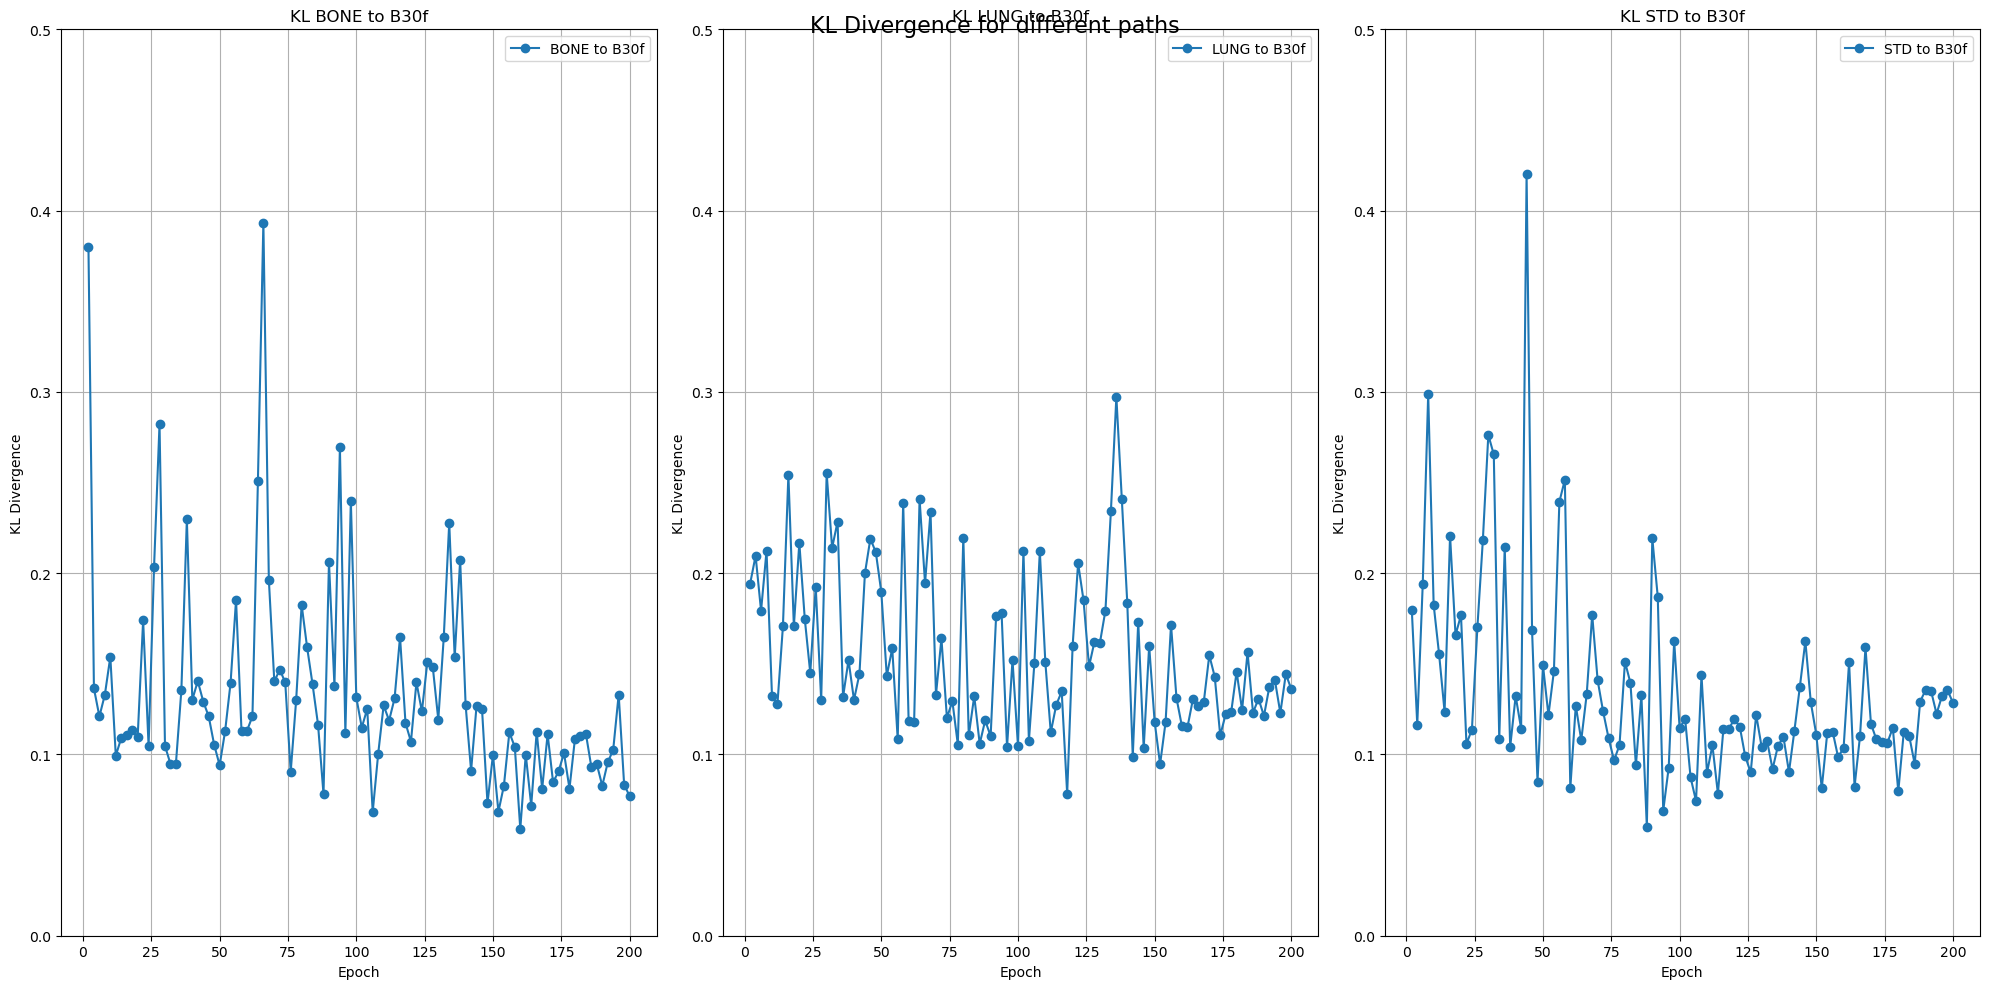

In [8]:
#Plot KL divergence
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
axes[0].plot(list(kl_bonetob30f_scores.keys()), list(kl_bonetob30f_scores.values()), marker='o', label='BONE to B30f')
axes[0].set_title('KL BONE to B30f')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('KL Divergence')
axes[0].set_ylim(0, 0.5)
axes[0].legend()
axes[0].grid()

axes[1].plot(list(kl_lungtob30f_scores.keys()), list(kl_lungtob30f_scores.values()), marker='o', label='LUNG to B30f')
axes[1].set_title('KL LUNG to B30f')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('KL Divergence')
axes[1].set_ylim(0, 0.5)
axes[1].legend()
axes[1].grid()  

axes[2].plot(list(kl_stdtob30f_scores.keys()), list(kl_stdtob30f_scores.values()), marker='o', label='STD to B30f')
axes[2].set_title('KL STD to B30f')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_ylim(0, 0.5)
axes[2].legend()
axes[2].grid()
plt.tight_layout()
fig.suptitle('KL Divergence for different paths', fontsize=16)
plt.show()

In [9]:
mse_b50ftob30f_ranks = rankdata(list(mse_b50ftob30f_scores.values()))
mse_b80ftob30f_ranks = rankdata(list(mse_b80ftob30f_scores.values()))
mse_bonetostd_ranks = rankdata(list(mse_bonetostd_scores.values()))
mse_lungtostd_ranks = rankdata(list(mse_lungtostd_scores.values()))
kl_bonetob30f_ranks = rankdata(list(kl_bonetob30f_scores.values()))
kl_lungtob30f_ranks = rankdata(list(kl_lungtob30f_scores.values()))
kl_stdtob30f_ranks = rankdata(list(kl_stdtob30f_scores.values())) 

print("MSE B50f to B30f Ranks:", mse_b50ftob30f_ranks)
print("MSE B80f to B30f Ranks:", mse_b80ftob30f_ranks)
print("MSE BONE to STD Ranks:", mse_bonetostd_ranks)
print("MSE LUNG to STD Ranks:", mse_lungtostd_ranks)
print("KL BONE to B30f Ranks:", kl_bonetob30f_ranks)
print("KL LUNG to B30f Ranks:", kl_lungtob30f_ranks)
print("KL STD to B30f Ranks:", kl_stdtob30f_ranks)


MSE B50f to B30f Ranks: [ 99.  97.  65.  71.  79.  74.  91.  82.  92.  98.  63. 100.  85.  64.
   5.  39.  96.  61.  95.  68.  45.  87.  46.  81.  57.  93.  67.  47.
  36.  20.  73.  60.  54.  70.  25.   1.   6.  76.  19.  90.  62.  56.
  49.  88.  40.   7.  15.  94.  37.  51.  83.  31.  66.  69.  86.  84.
  80.  89.  42.  50.  33.   9.  10.  53.   4.  11.  77.  27.  24.   3.
  48.   2.   8.  26.  17.  28.  22.  34.  78.  41.  75.  59.  29.  52.
  13.  72.  32.  43.  21.  38.  12.  44.  14.  55.  35.  23.  30.  58.
  18.  16.]
MSE B80f to B30f Ranks: [100.  99.  48.  67.  71.  93.  98.  96.  77.  90.  60.  59.  70.  92.
  23.  43.  86.  82.  91.  65.  38.  88.  66.  95.  78.  87.  52.  16.
  74.  32.  31.  89.  36.  83.   5.  75.  55.  76.  22.  79.  30.  97.
  17.  94.  64.   9.  34.  46.  73.  81.  58.  40.  47.  45.  84.   8.
  41.  85.   1.  25.  51.   2.  28.  50.  35.  68.  56.  62.  13.  11.
  12.  10.   6.  37.  39.  57.  24.  80.  33.  63.  69.  44.  20.  42.
  49.   3.  29.  

In [11]:
mse_b50ftob30f_rank = {list(mse_b50ftob30f_scores.keys())[i]: mse_b50ftob30f_ranks[i] for i in range(len(mse_b50ftob30f_ranks))}
mse_b80ftob30f_rank = {list(mse_b80ftob30f_scores.keys())[i]: mse_b80ftob30f_ranks[i] for i in range(len(mse_b80ftob30f_ranks))}
mse_bonetostd_rank = {list(mse_bonetostd_scores.keys())[i]: mse_bonetostd_ranks[i] for i in range(len(mse_bonetostd_ranks))}
mse_lungtostd_rank = {list(mse_lungtostd_scores.keys())[i]: mse_lungtostd_ranks[i] for i in range(len(mse_lungtostd_ranks))}
kl_bonetob30f_rank = {list(kl_bonetob30f_scores.keys())[i]: kl_bonetob30f_ranks[i] for i in range(len(kl_bonetob30f_ranks))}
kl_lungtob30f_rank = {list(kl_lungtob30f_scores.keys())[i]: kl_lungtob30f_ranks[i] for i in range(len(kl_lungtob30f_ranks))}
kl_stdtob30f_rank = {list(kl_stdtob30f_scores.keys())[i]: kl_stdtob30f_ranks[i] for i in range(len(kl_stdtob30f_ranks))} 

print("Ranked MSE B50f to B30f:", mse_b50ftob30f_rank)
print("Ranked MSE B80f to B30f:", mse_b80ftob30f_rank)
print("Ranked MSE BONE to STD:", mse_bonetostd_rank)
print("Ranked MSE LUNG to STD:", mse_lungtostd_rank)
print("Ranked KL BONE to B30f:", kl_bonetob30f_rank)
print("Ranked KL LUNG to B30f:", kl_lungtob30f_rank)
print("Ranked KL STD to B30f:", kl_stdtob30f_rank)


Ranked MSE B50f to B30f: {2: 99.0, 4: 97.0, 6: 65.0, 8: 71.0, 10: 79.0, 12: 74.0, 14: 91.0, 16: 82.0, 18: 92.0, 20: 98.0, 22: 63.0, 24: 100.0, 26: 85.0, 28: 64.0, 30: 5.0, 32: 39.0, 34: 96.0, 36: 61.0, 38: 95.0, 40: 68.0, 42: 45.0, 44: 87.0, 46: 46.0, 48: 81.0, 50: 57.0, 52: 93.0, 54: 67.0, 56: 47.0, 58: 36.0, 60: 20.0, 62: 73.0, 64: 60.0, 66: 54.0, 68: 70.0, 70: 25.0, 72: 1.0, 74: 6.0, 76: 76.0, 78: 19.0, 80: 90.0, 82: 62.0, 84: 56.0, 86: 49.0, 88: 88.0, 90: 40.0, 92: 7.0, 94: 15.0, 96: 94.0, 98: 37.0, 100: 51.0, 102: 83.0, 104: 31.0, 106: 66.0, 108: 69.0, 110: 86.0, 112: 84.0, 114: 80.0, 116: 89.0, 118: 42.0, 120: 50.0, 122: 33.0, 124: 9.0, 126: 10.0, 128: 53.0, 130: 4.0, 132: 11.0, 134: 77.0, 136: 27.0, 138: 24.0, 140: 3.0, 142: 48.0, 144: 2.0, 146: 8.0, 148: 26.0, 150: 17.0, 152: 28.0, 154: 22.0, 156: 34.0, 158: 78.0, 160: 41.0, 162: 75.0, 164: 59.0, 166: 29.0, 168: 52.0, 170: 13.0, 172: 72.0, 174: 32.0, 176: 43.0, 178: 21.0, 180: 38.0, 182: 12.0, 184: 44.0, 186: 14.0, 188: 55.0, 1

In [12]:
mse_b50ftob30f_rank = dict(sorted(mse_b50ftob30f_rank.items()))
mse_b80ftob30f_rank = dict(sorted(mse_b80ftob30f_rank.items()))
mse_bonetostd_rank = dict(sorted(mse_bonetostd_rank.items()))
mse_lungtostd_rank = dict(sorted(mse_lungtostd_rank.items()))
kl_bonetob30f_rank = dict(sorted(kl_bonetob30f_rank.items()))
kl_lungtob30f_rank = dict(sorted(kl_lungtob30f_rank.items()))
kl_stdtob30f_rank = dict(sorted(kl_stdtob30f_rank.items()))

print("Sorted Ranked MSE B50f to B30f:", mse_b50ftob30f_rank)
print("Sorted Ranked MSE B80f to B30f:", mse_b80ftob30f_rank)
print("Sorted Ranked MSE BONE to STD:", mse_bonetostd_rank)
print("Sorted Ranked MSE LUNG to STD:", mse_lungtostd_rank)
print("Sorted Ranked KL BONE to B30f:", kl_bonetob30f_rank)
print("Sorted Ranked KL LUNG to B30f:", kl_lungtob30f_rank)
print("Sorted Ranked KL STD to B30f:", kl_stdtob30f_rank)


Sorted Ranked MSE B50f to B30f: {2: 99.0, 4: 97.0, 6: 65.0, 8: 71.0, 10: 79.0, 12: 74.0, 14: 91.0, 16: 82.0, 18: 92.0, 20: 98.0, 22: 63.0, 24: 100.0, 26: 85.0, 28: 64.0, 30: 5.0, 32: 39.0, 34: 96.0, 36: 61.0, 38: 95.0, 40: 68.0, 42: 45.0, 44: 87.0, 46: 46.0, 48: 81.0, 50: 57.0, 52: 93.0, 54: 67.0, 56: 47.0, 58: 36.0, 60: 20.0, 62: 73.0, 64: 60.0, 66: 54.0, 68: 70.0, 70: 25.0, 72: 1.0, 74: 6.0, 76: 76.0, 78: 19.0, 80: 90.0, 82: 62.0, 84: 56.0, 86: 49.0, 88: 88.0, 90: 40.0, 92: 7.0, 94: 15.0, 96: 94.0, 98: 37.0, 100: 51.0, 102: 83.0, 104: 31.0, 106: 66.0, 108: 69.0, 110: 86.0, 112: 84.0, 114: 80.0, 116: 89.0, 118: 42.0, 120: 50.0, 122: 33.0, 124: 9.0, 126: 10.0, 128: 53.0, 130: 4.0, 132: 11.0, 134: 77.0, 136: 27.0, 138: 24.0, 140: 3.0, 142: 48.0, 144: 2.0, 146: 8.0, 148: 26.0, 150: 17.0, 152: 28.0, 154: 22.0, 156: 34.0, 158: 78.0, 160: 41.0, 162: 75.0, 164: 59.0, 166: 29.0, 168: 52.0, 170: 13.0, 172: 72.0, 174: 32.0, 176: 43.0, 178: 21.0, 180: 38.0, 182: 12.0, 184: 44.0, 186: 14.0, 188: 

In [ ]:
#Rank the data for mse and kl divergence
mse_b50ftob30f_ranks = rankdata(list(mse_b50ftob30f_scores.values()))
mse_b80ftob30f_ranks = rankdata(list(mse_b80ftob30f_scores.values()))
mse_bonetostd_ranks = rankdata(list(mse_bonetostd_scores.values()))
mse_lungtostd_ranks = rankdata(list(mse_lungtostd_scores.values()))
kl_bonetob30f_ranks = rankdata(list(kl_bonetob30f_scores.values()))
kl_lungtob30f_ranks = rankdata(list(kl_lungtob30f_scores.values()))
kl_stdtob30f_ranks = rankdata(list(kl_stdtob30f_scores.values())) 

mse_b50ftob30f_rank = {list(mse_b50ftob30f_scores.keys())[i]: mse_b50ftob30f_ranks[i] for i in range(len(mse_b50ftob30f_ranks))}
mse_b80ftob30f_rank = {list(mse_b80ftob30f_scores.keys())[i]: mse_b80ftob30f_ranks[i] for i in range(len(mse_b80ftob30f_ranks))}
mse_bonetostd_rank = {list(mse_bonetostd_scores.keys())[i]: mse_bonetostd_ranks[i] for i in range(len(mse_bonetostd_ranks))}
mse_lungtostd_rank = {list(mse_lungtostd_scores.keys())[i]: mse_lungtostd_ranks[i] for i in range(len(mse_lungtostd_ranks))}
kl_bonetob30f_rank = {list(kl_bonetob30f_scores.keys())[i]: kl_bonetob30f_ranks[i] for i in range(len(kl_bonetob30f_ranks))}
kl_lungtob30f_rank = {list(kl_lungtob30f_scores.keys())[i]: kl_lungtob30f_ranks[i] for i in range(len(kl_lungtob30f_ranks))}
kl_stdtob30f_rank = {list(kl_stdtob30f_scores.keys())[i]: kl_stdtob30f_ranks[i] for i in range(len(kl_stdtob30f_ranks))} 

mse_b50ftob30f_rank = dict(sorted(mse_b50ftob30f_rank.items()))
mse_b80ftob30f_rank = dict(sorted(mse_b80ftob30f_rank.items()))
mse_bonetostd_rank = dict(sorted(mse_bonetostd_rank.items()))
mse_lungtostd_rank = dict(sorted(mse_lungtostd_rank.items()))
kl_bonetob30f_rank = dict(sorted(kl_bonetob30f_rank.items()))
kl_lungtob30f_rank = dict(sorted(kl_lungtob30f_rank.items()))
kl_stdtob30f_rank = dict(sorted(kl_stdtob30f_rank.items()))

In [15]:
kl_bonetob30f_rank

{2: 99.0,
 4: 70.0,
 6: 53.0,
 8: 67.0,
 10: 82.0,
 12: 23.0,
 14: 35.0,
 16: 38.0,
 18: 47.0,
 20: 36.0,
 22: 86.0,
 24: 31.0,
 26: 90.0,
 28: 98.0,
 30: 30.0,
 32: 20.0,
 34: 21.0,
 36: 69.0,
 38: 94.0,
 40: 64.0,
 42: 77.0,
 44: 62.0,
 46: 54.0,
 48: 32.0,
 50: 18.0,
 52: 45.0,
 54: 73.0,
 56: 88.0,
 58: 44.0,
 60: 46.0,
 62: 55.0,
 64: 96.0,
 66: 100.0,
 68: 89.0,
 70: 76.0,
 72: 78.0,
 74: 74.0,
 76: 14.0,
 78: 63.0,
 80: 87.0,
 82: 83.0,
 84: 72.0,
 86: 49.0,
 88: 7.0,
 90: 91.0,
 92: 71.0,
 94: 97.0,
 96: 41.0,
 98: 95.0,
 100: 66.0,
 102: 48.0,
 104: 58.0,
 106: 2.0,
 108: 26.0,
 110: 60.0,
 112: 51.0,
 114: 65.0,
 116: 85.0,
 118: 50.0,
 120: 33.0,
 122: 75.0,
 124: 56.0,
 126: 80.0,
 128: 79.0,
 130: 52.0,
 132: 84.0,
 134: 93.0,
 136: 81.0,
 138: 92.0,
 140: 61.0,
 142: 16.0,
 144: 59.0,
 146: 57.0,
 148: 5.0,
 150: 24.0,
 152: 3.0,
 154: 11.0,
 156: 42.0,
 158: 29.0,
 160: 1.0,
 162: 25.0,
 164: 4.0,
 166: 43.0,
 168: 8.0,
 170: 39.0,
 172: 13.0,
 174: 15.0,
 176: 27.0,
 17

In [12]:
overall_stage_one_rank = {}
for key in mse_b50ftob30f_rank.keys():
    overall_stage_one_rank[key] = (mse_b50ftob30f_rank[key] + mse_b80ftob30f_rank[key] + mse_bonetostd_rank[key] + mse_lungtostd_rank[key] + 
                                   kl_bonetob30f_rank[key] + kl_lungtob30f_rank[key] + kl_stdtob30f_rank[key])
    # overall_stage_one_rank[key] = (0.5*kl_bonetob30f_rank[key] + 0.5*kl_lungtob30f_rank[key] + 0.5*kl_stdtob30f_rank[key] + 0.5*mse_b50ftob30f_rank[key] + 0.5*mse_b80ftob30f_rank[key])


In [13]:
overall_stage_one_rank

{2: 650.0,
 4: 571.0,
 6: 453.0,
 8: 513.0,
 10: 505.0,
 12: 392.0,
 14: 490.0,
 16: 564.0,
 18: 528.0,
 20: 542.0,
 22: 485.0,
 24: 410.0,
 26: 573.0,
 28: 520.0,
 30: 408.0,
 32: 477.0,
 34: 410.0,
 36: 468.0,
 38: 550.0,
 40: 439.0,
 42: 311.0,
 44: 572.0,
 46: 507.0,
 48: 450.0,
 50: 426.0,
 52: 441.0,
 54: 458.0,
 56: 423.0,
 58: 517.0,
 60: 204.0,
 62: 352.0,
 64: 509.0,
 66: 503.0,
 68: 515.0,
 70: 361.0,
 72: 422.0,
 74: 287.0,
 76: 413.0,
 78: 313.0,
 80: 508.0,
 82: 309.0,
 84: 367.0,
 86: 227.0,
 88: 270.0,
 90: 393.0,
 92: 306.0,
 94: 330.0,
 96: 353.0,
 98: 410.0,
 100: 332.0,
 102: 454.0,
 104: 209.0,
 106: 277.0,
 108: 327.0,
 110: 455.0,
 112: 243.0,
 114: 252.0,
 116: 484.0,
 118: 232.0,
 120: 401.0,
 122: 402.0,
 124: 242.0,
 126: 233.0,
 128: 362.0,
 130: 251.0,
 132: 407.0,
 134: 460.0,
 136: 382.0,
 138: 349.0,
 140: 203.0,
 142: 207.0,
 144: 370.0,
 146: 253.0,
 148: 239.0,
 150: 233.0,
 152: 155.0,
 154: 164.0,
 156: 327.0,
 158: 243.0,
 160: 187.0,
 162: 371.0,


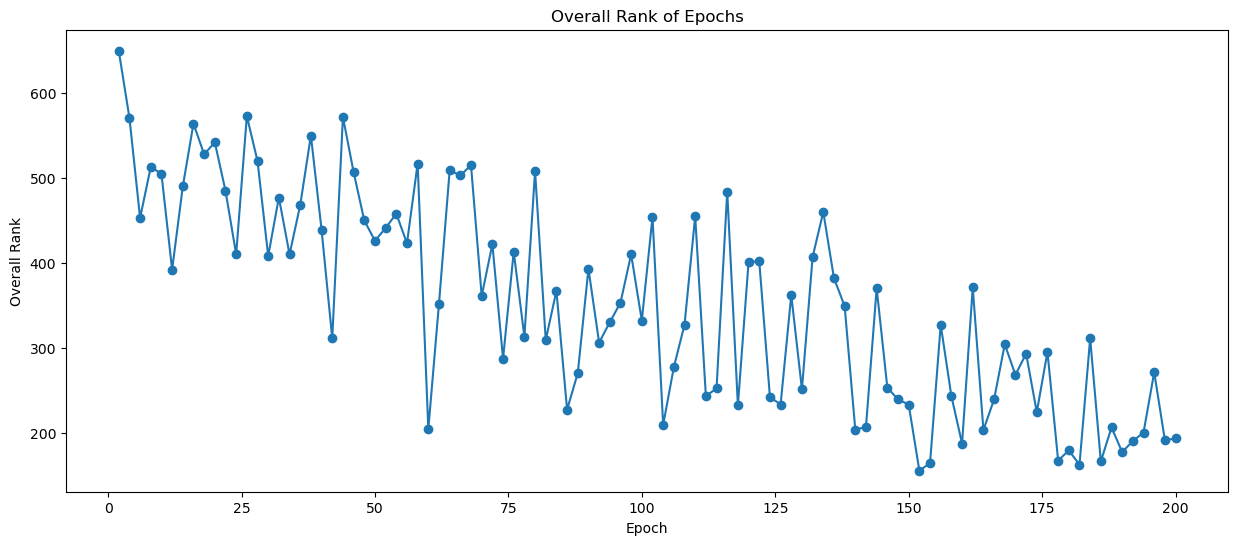

In [14]:
plt.figure(figsize=(15, 6))
plt.plot(list(overall_stage_one_rank.keys()), list(overall_stage_one_rank.values()), marker='o')
plt.xlabel("Epoch")
plt.ylabel("Overall Rank")
plt.title("Overall Rank of Epochs")
plt.show()

In [32]:
#Lowest rank is the best epoch
best_epoch = min(overall_stage_one_rank, key=overall_stage_one_rank.get)
print(f"The best epoch is: {best_epoch} with rank {overall_stage_one_rank[best_epoch]}")

#Second best epoch
second_best_epoch = sorted(overall_stage_one_rank, key=overall_stage_one_rank.get)[1]
print(f"The second best epoch is: {second_best_epoch} with rank {overall_stage_one_rank[second_best_epoch]}") 

third_best_epoch = sorted(overall_stage_one_rank, key=overall_stage_one_rank.get)[2]
print(f"The third best epoch is: {third_best_epoch} with rank {overall_stage_one_rank[third_best_epoch]}")

The best epoch is: 152 with rank 77.5
The second best epoch is: 182 with rank 81.0
The third best epoch is: 154 with rank 82.0


In [ ]:
#Epoch 152 results 
b50ftob30f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation/B50ftoB30f_emphysema/epoch_{best_epoch}/emph.csv")
b50ftob30f_best = b50ftob30f_best.sort_values(by='pid')
b80ftob30f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation/B80ftoB30f_emphysema/epoch_{best_epoch}/emph.csv")
b80ftob30f_best = b80ftob30f_best.sort_values(by='pid')
bonetostd_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation/BONEtoSTANDARD_emphysema/epoch_{best_epoch}/emph.csv")
bonetostd_best = bonetostd_best.sort_values(by='pid')
lungtostd_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation/LUNGtoSTANDARD_emphysema/epoch_{best_epoch}/emph.csv")
lungtostd_best = lungtostd_best.sort_values(by='pid')
bonetob30f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation/BONEtoB30f_emphysema/epoch_{best_epoch}/emph.csv")
bonetob30f_best = bonetob30f_best.sort_values(by='pid')
lungtob30f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation/LUNGtoB30f_emphysema/epoch_{best_epoch}/emph.csv")
lungtob30f_best = lungtob30f_best.sort_values(by='pid')
stdtob30f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation/STANDARDtoB30f_emphysema/epoch_{best_epoch}/emph.csv") #Used the STANDARD from BONE_STANDARD pair. 
stdtob30f_best = stdtob30f_best.sort_values(by='pid')

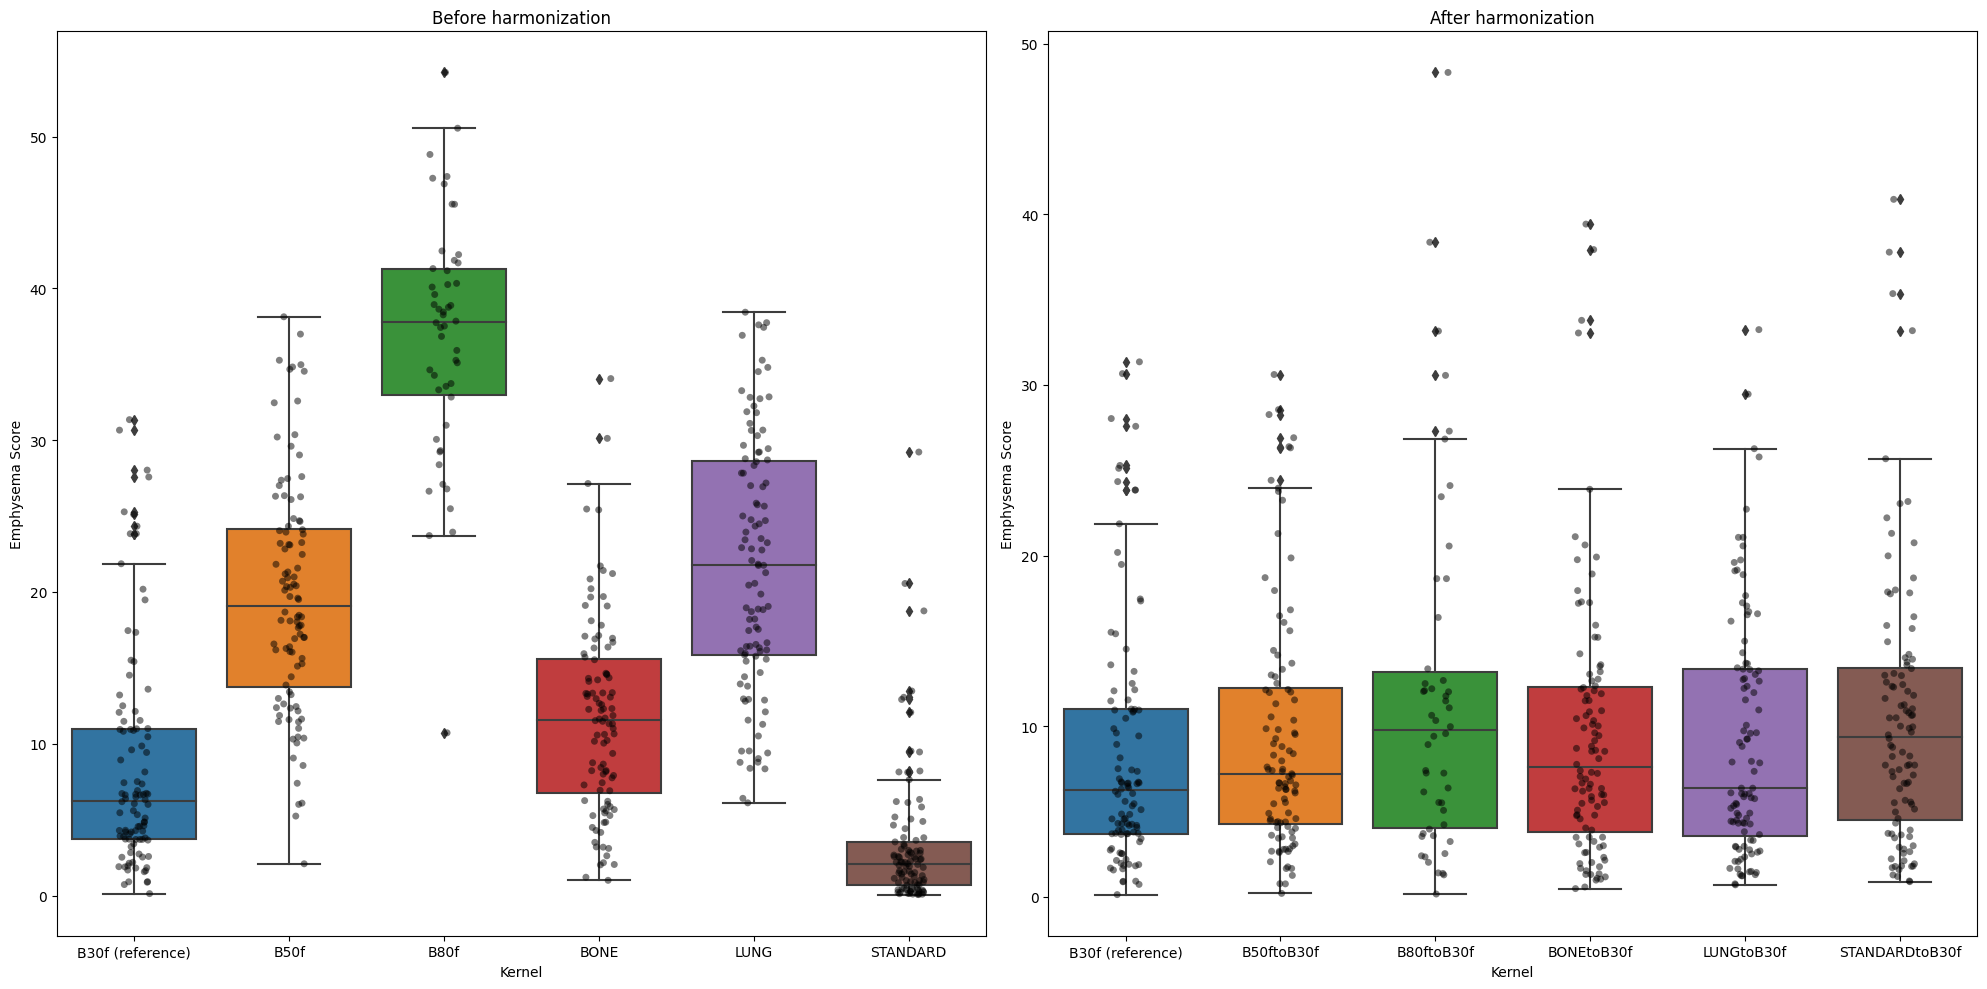

In [15]:
fig, axes = plt.subplots(1,2 , figsize=(20, 10))
sns.boxplot(data=[b30f_b50f['emph_score'], b50f['emph_score'], b80f['emph_score'], bone['emph_score'], lung['emph_score'], std_bone['emph_score']],
            ax=axes[0])
sns.stripplot(data=[b30f_b50f['emph_score'], b50f['emph_score'], b80f['emph_score'], bone['emph_score'], lung['emph_score'], std_bone['emph_score']],
              ax=axes[0], color='black', alpha=0.5, jitter=True)
axes[0].set_xticks([0, 1, 2, 3, 4, 5])
axes[0].set_xticklabels(['B30f (reference)', 'B50f', 'B80f', 'BONE', 'LUNG', 'STANDARD'])
axes[0].set_title('Before harmonization')
axes[0].set_ylabel('Emphysema Score')
axes[0].set_xlabel('Kernel')

sns.boxplot(data=[b30f_b50f['emph_score'], b50ftob30f_best['emph_score'], b80ftob30f_best['emph_score'], bonetob30f_best['emph_score'], lungtob30f_best['emph_score'], stdtob30f_best['emph_score']],
            ax=axes[1])
sns.stripplot(data=[b30f_b50f['emph_score'], b50ftob30f_best['emph_score'], b80ftob30f_best['emph_score'], bonetob30f_best['emph_score'], lungtob30f_best['emph_score'], stdtob30f_best['emph_score']],
              ax=axes[1], color='black', alpha=0.5, jitter=True)
axes[1].set_xticks([0, 1, 2, 3, 4, 5])
axes[1].set_xticklabels(['B30f (reference)', 'B50ftoB30f', 'B80ftoB30f', 'BONEtoB30f', 'LUNGtoB30f', 'STANDARDtoB30f'])
axes[1].set_title('After harmonization')
axes[1].set_ylabel('Emphysema Score')
axes[1].set_xlabel('Kernel')

plt.tight_layout()
plt.show()

In [95]:
#Paired data emphysema scores: Bland Altman analysis
def bland_altman_conversion_without_mean(hard, soft, converted,x_plot_range, y_plot_range):
    sd_limit = 1.96
    # annotation_font_size = 15
    annotation_font_size = 16

    fig, ax = plt.subplots(figsize=(10, 5), facecolor = "w")

    scatter_kwds = {'s': 20}
    mean_line_kwds = {}
    limit_lines_kwds = {}
    for kwds in [mean_line_kwds, limit_lines_kwds]:
        # if 'color' not in kwds:
        #     kwds['color'] = 'gray'
        if 'linewidth' not in kwds:
            kwds['linewidth'] = 2


    diff_list_before = np.array(hard) - np.array(soft)

    mean_diff_before = np.mean(diff_list_before)
    std_diff_before = np.std(diff_list_before)

    diff_list_after = np.array(converted) - np.array(soft)

    mean_diff_after = np.mean(diff_list_after)
    std_diff_after = np.std(diff_list_after)
    
    plt.title("Agreement before and after kernel harmonization", fontsize = 18)

    ax.scatter(np.array(soft),diff_list_before, color='blue',s=10,alpha=0.5)
    ax.scatter(np.array(soft),diff_list_after, color='red',s=10,alpha=0.3)

    ax.set_ylim(y_plot_range[0], y_plot_range[1])
    ax.set_xlim(x_plot_range[0], x_plot_range[1])

    limit_of_agreement_before = sd_limit * std_diff_before
    lower_before = mean_diff_before - limit_of_agreement_before
    upper_before = mean_diff_before + limit_of_agreement_before 

    limit_of_agreement_after = sd_limit * std_diff_after
    lower_after = mean_diff_after - limit_of_agreement_after
    upper_after = mean_diff_after + limit_of_agreement_after 

    
    # for j, lim in enumerate([lower, upper]):
    ax.axhline(lower_before, linestyle='dotted', label=f'Before Conversion: -1.96 SD = {np.round(lower_before, 2)}',
               color='blue', alpha=0.5, **limit_lines_kwds)
    ax.axhline(upper_before, linestyle='dashed', label=f'Before Conversion: +1.96 SD = {np.round(upper_before, 2)}',
               color='blue', alpha=0.5, **limit_lines_kwds)
    ax.axhline(mean_diff_before, linestyle='solid', color='blue',
               label=f'Before Conversion: Mean Difference = {np.round(mean_diff_before, 2)}', alpha=0.5, **mean_line_kwds)
    

    ax.axhline(lower_after, linestyle='dotted', label=f'After Conversion: -1.96 SD = {np.round(lower_after, 2)}',
               color='red', alpha=0.5, **limit_lines_kwds)
    ax.axhline(upper_after, linestyle='dashed', label=f'After Conversion: +1.96 SD = {np.round(upper_after, 2)}',
               color='red', alpha=0.5, **limit_lines_kwds)
    ax.axhline(mean_diff_after, linestyle='solid', color='red',
               label=f'After Conversion: Mean Difference = {np.round(mean_diff_after, 2)}', alpha=0.5, **mean_line_kwds)

    ax.set_ylabel("Difference between measures of emphysema", fontsize=annotation_font_size)
    ax.set_xlabel("Ground truth emphysema measurement", fontsize=annotation_font_size)
    ax.tick_params(axis='x', labelsize=annotation_font_size)
    ax.tick_params(axis='y', labelsize=annotation_font_size)

    ax.legend(loc='best', fontsize=int(round(0.9 * annotation_font_size)))
    plt.gcf().set_dpi(300)
    # plt.savefig("bland_altman_emphysema.png", dpi = 300)
    plt.show() 

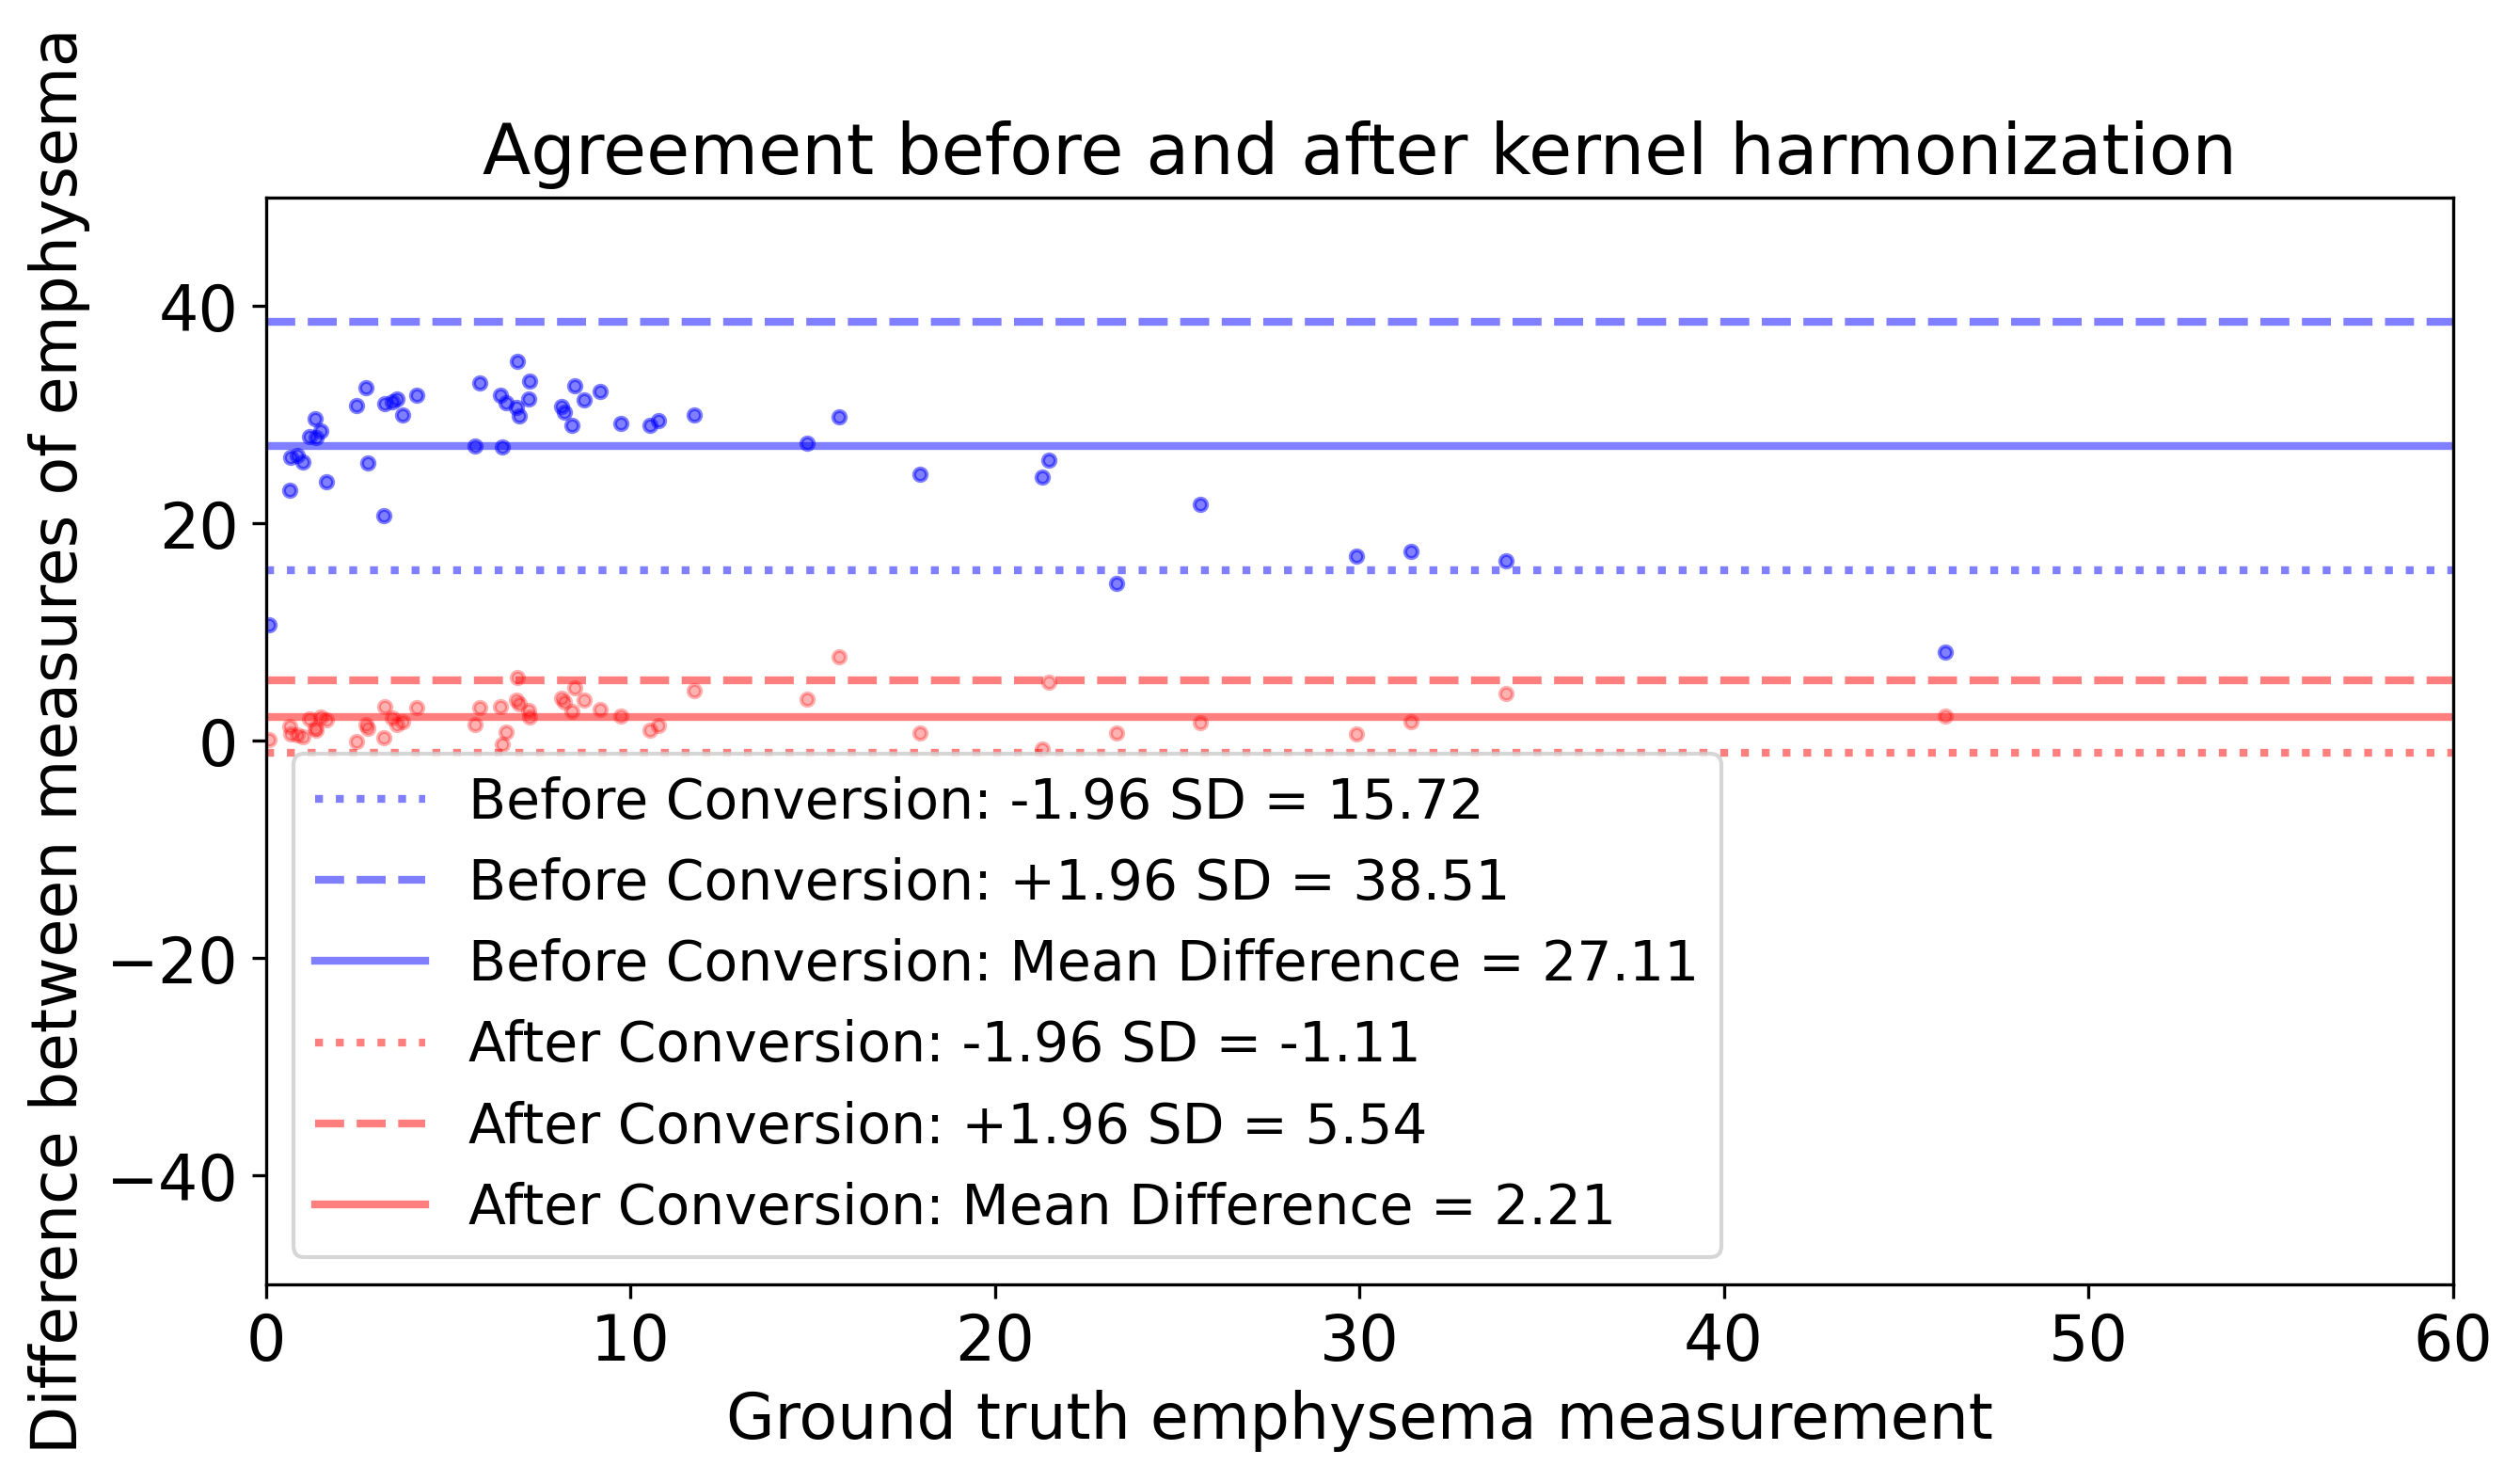

In [96]:
bland_altman_conversion_without_mean(b80f['emph_score'], b30f_b80f['emph_score'], b80ftob30f_best['emph_score'],
                                      x_plot_range = [0, 60], y_plot_range = [-50, 50])

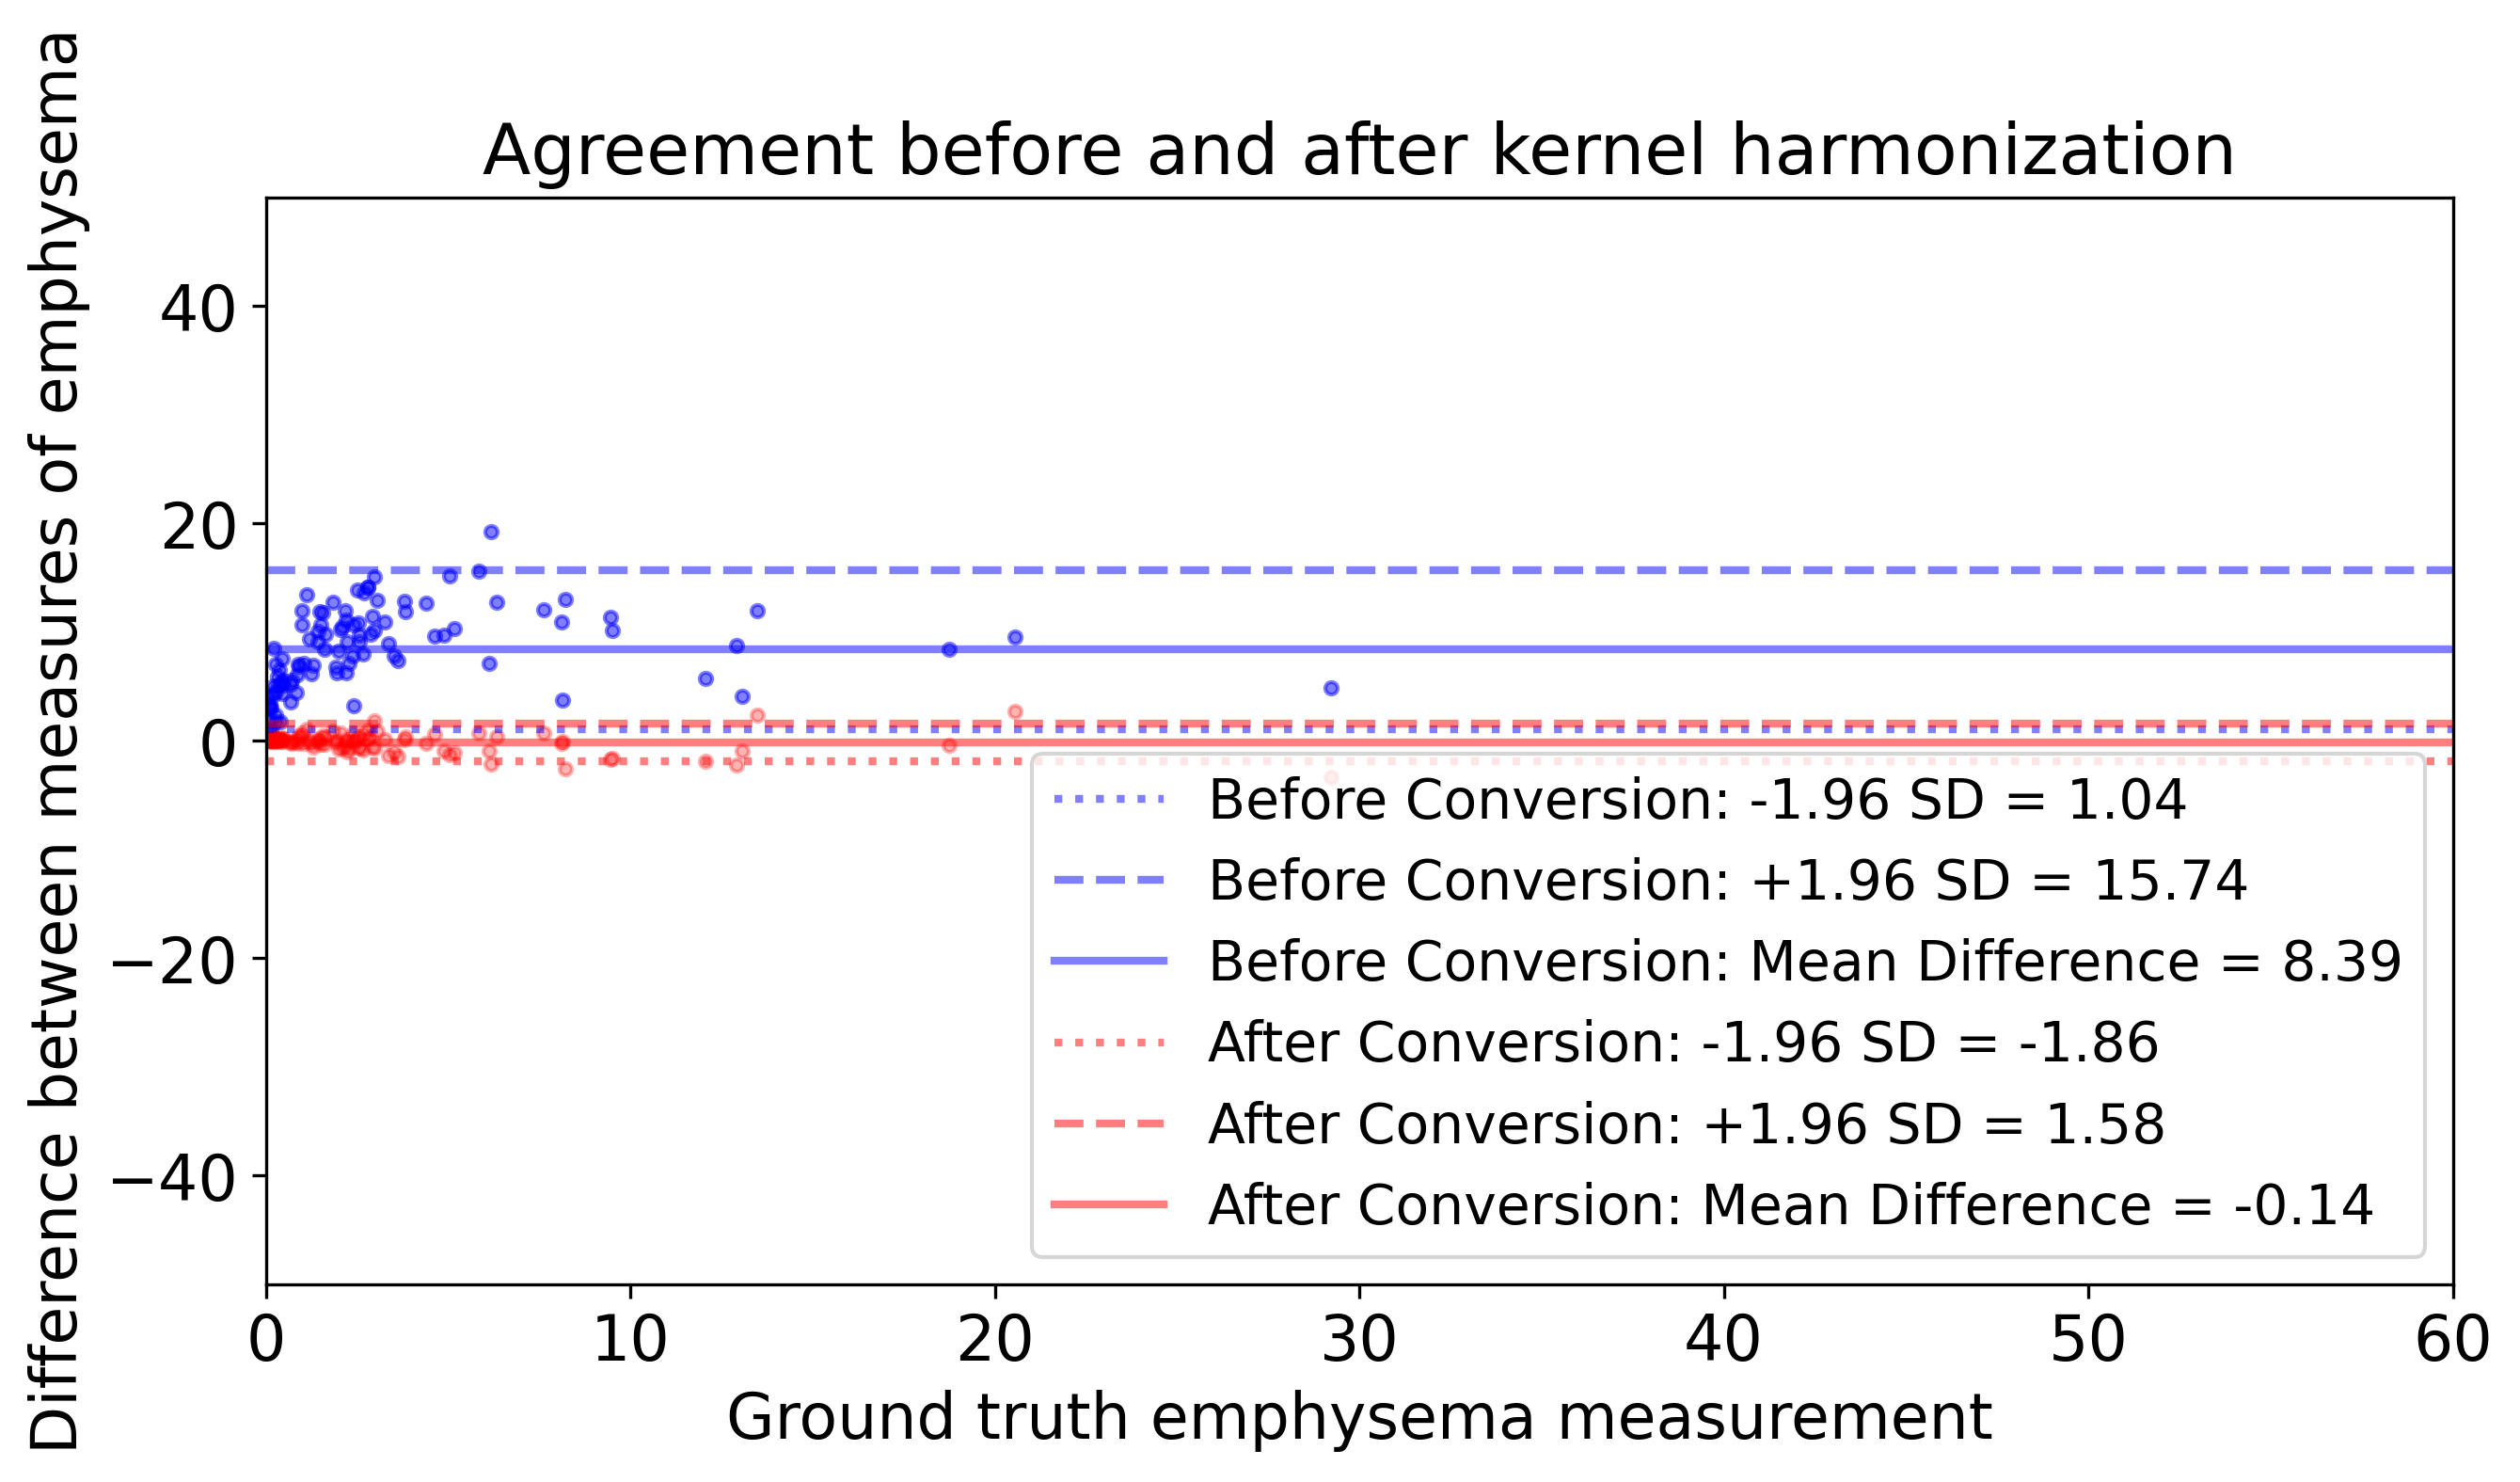

In [97]:
bland_altman_conversion_without_mean(bone['emph_score'], std_bone['emph_score'], bonetostd_best['emph_score'],
                                      x_plot_range = [0, 60], y_plot_range = [-50, 50])

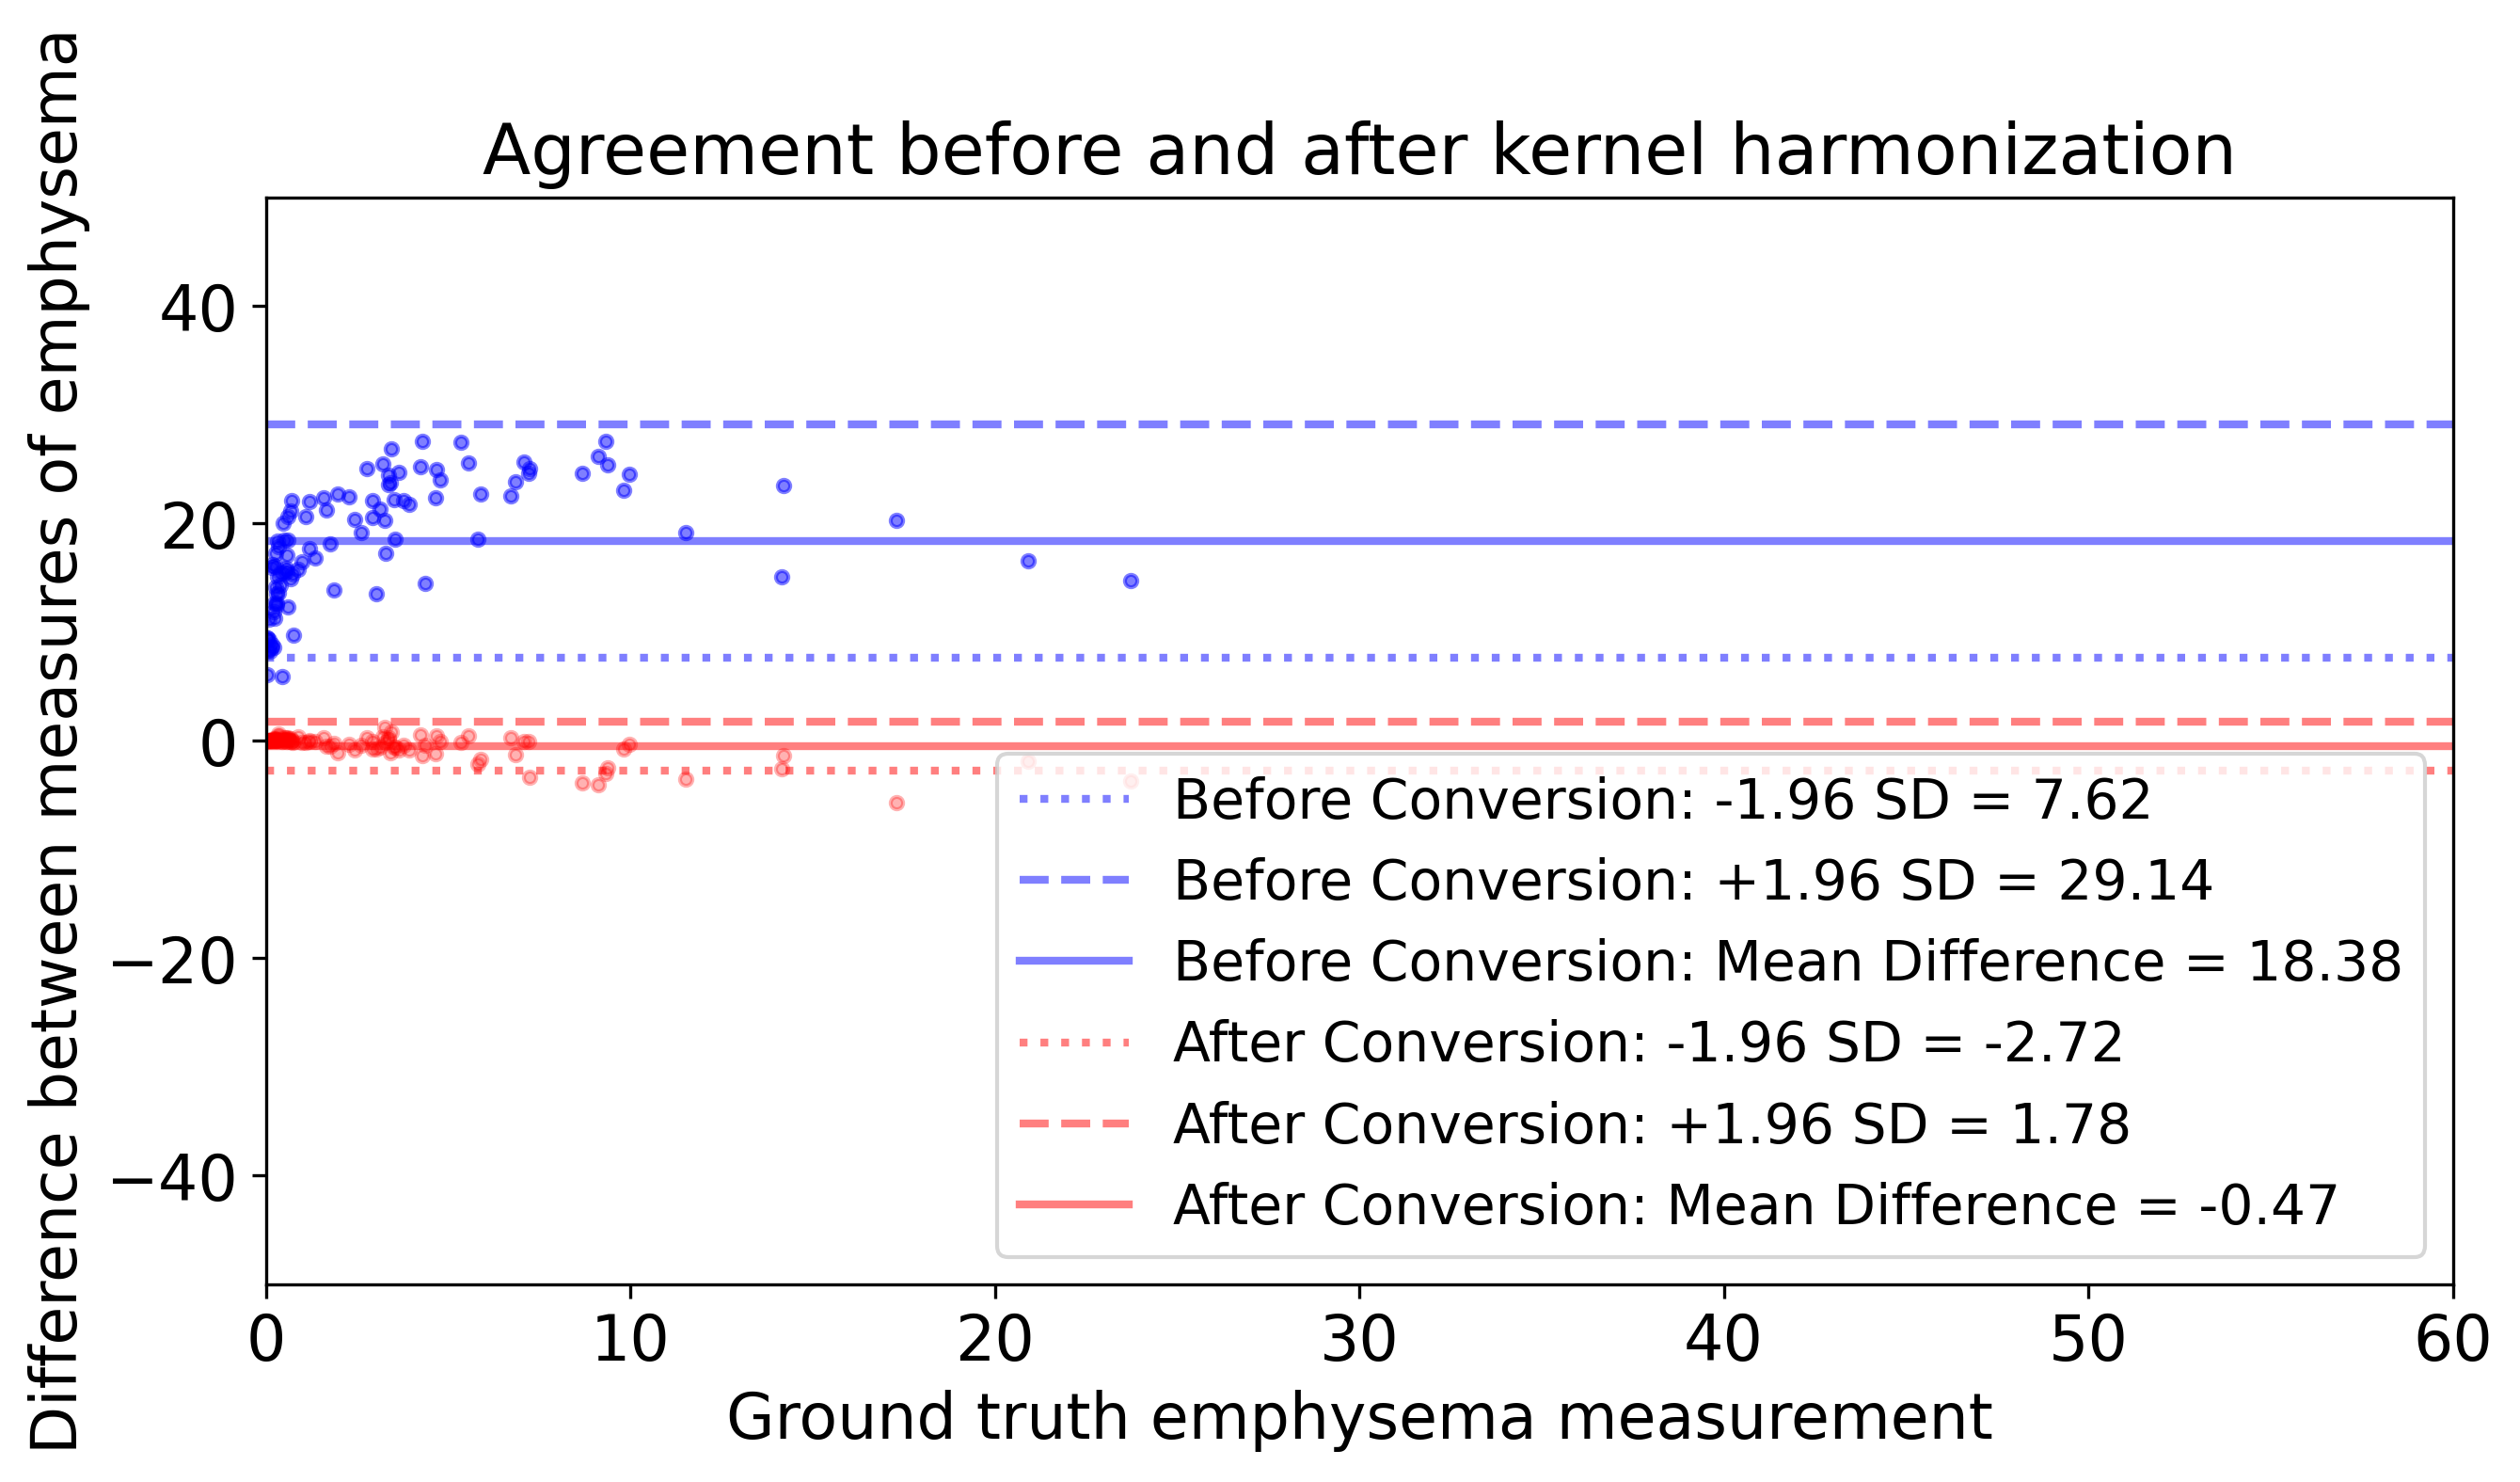

In [98]:
bland_altman_conversion_without_mean(lung['emph_score'], std_lung['emph_score'], lungtostd_best['emph_score'],
                                      x_plot_range = [0, 60], y_plot_range = [-50, 50])

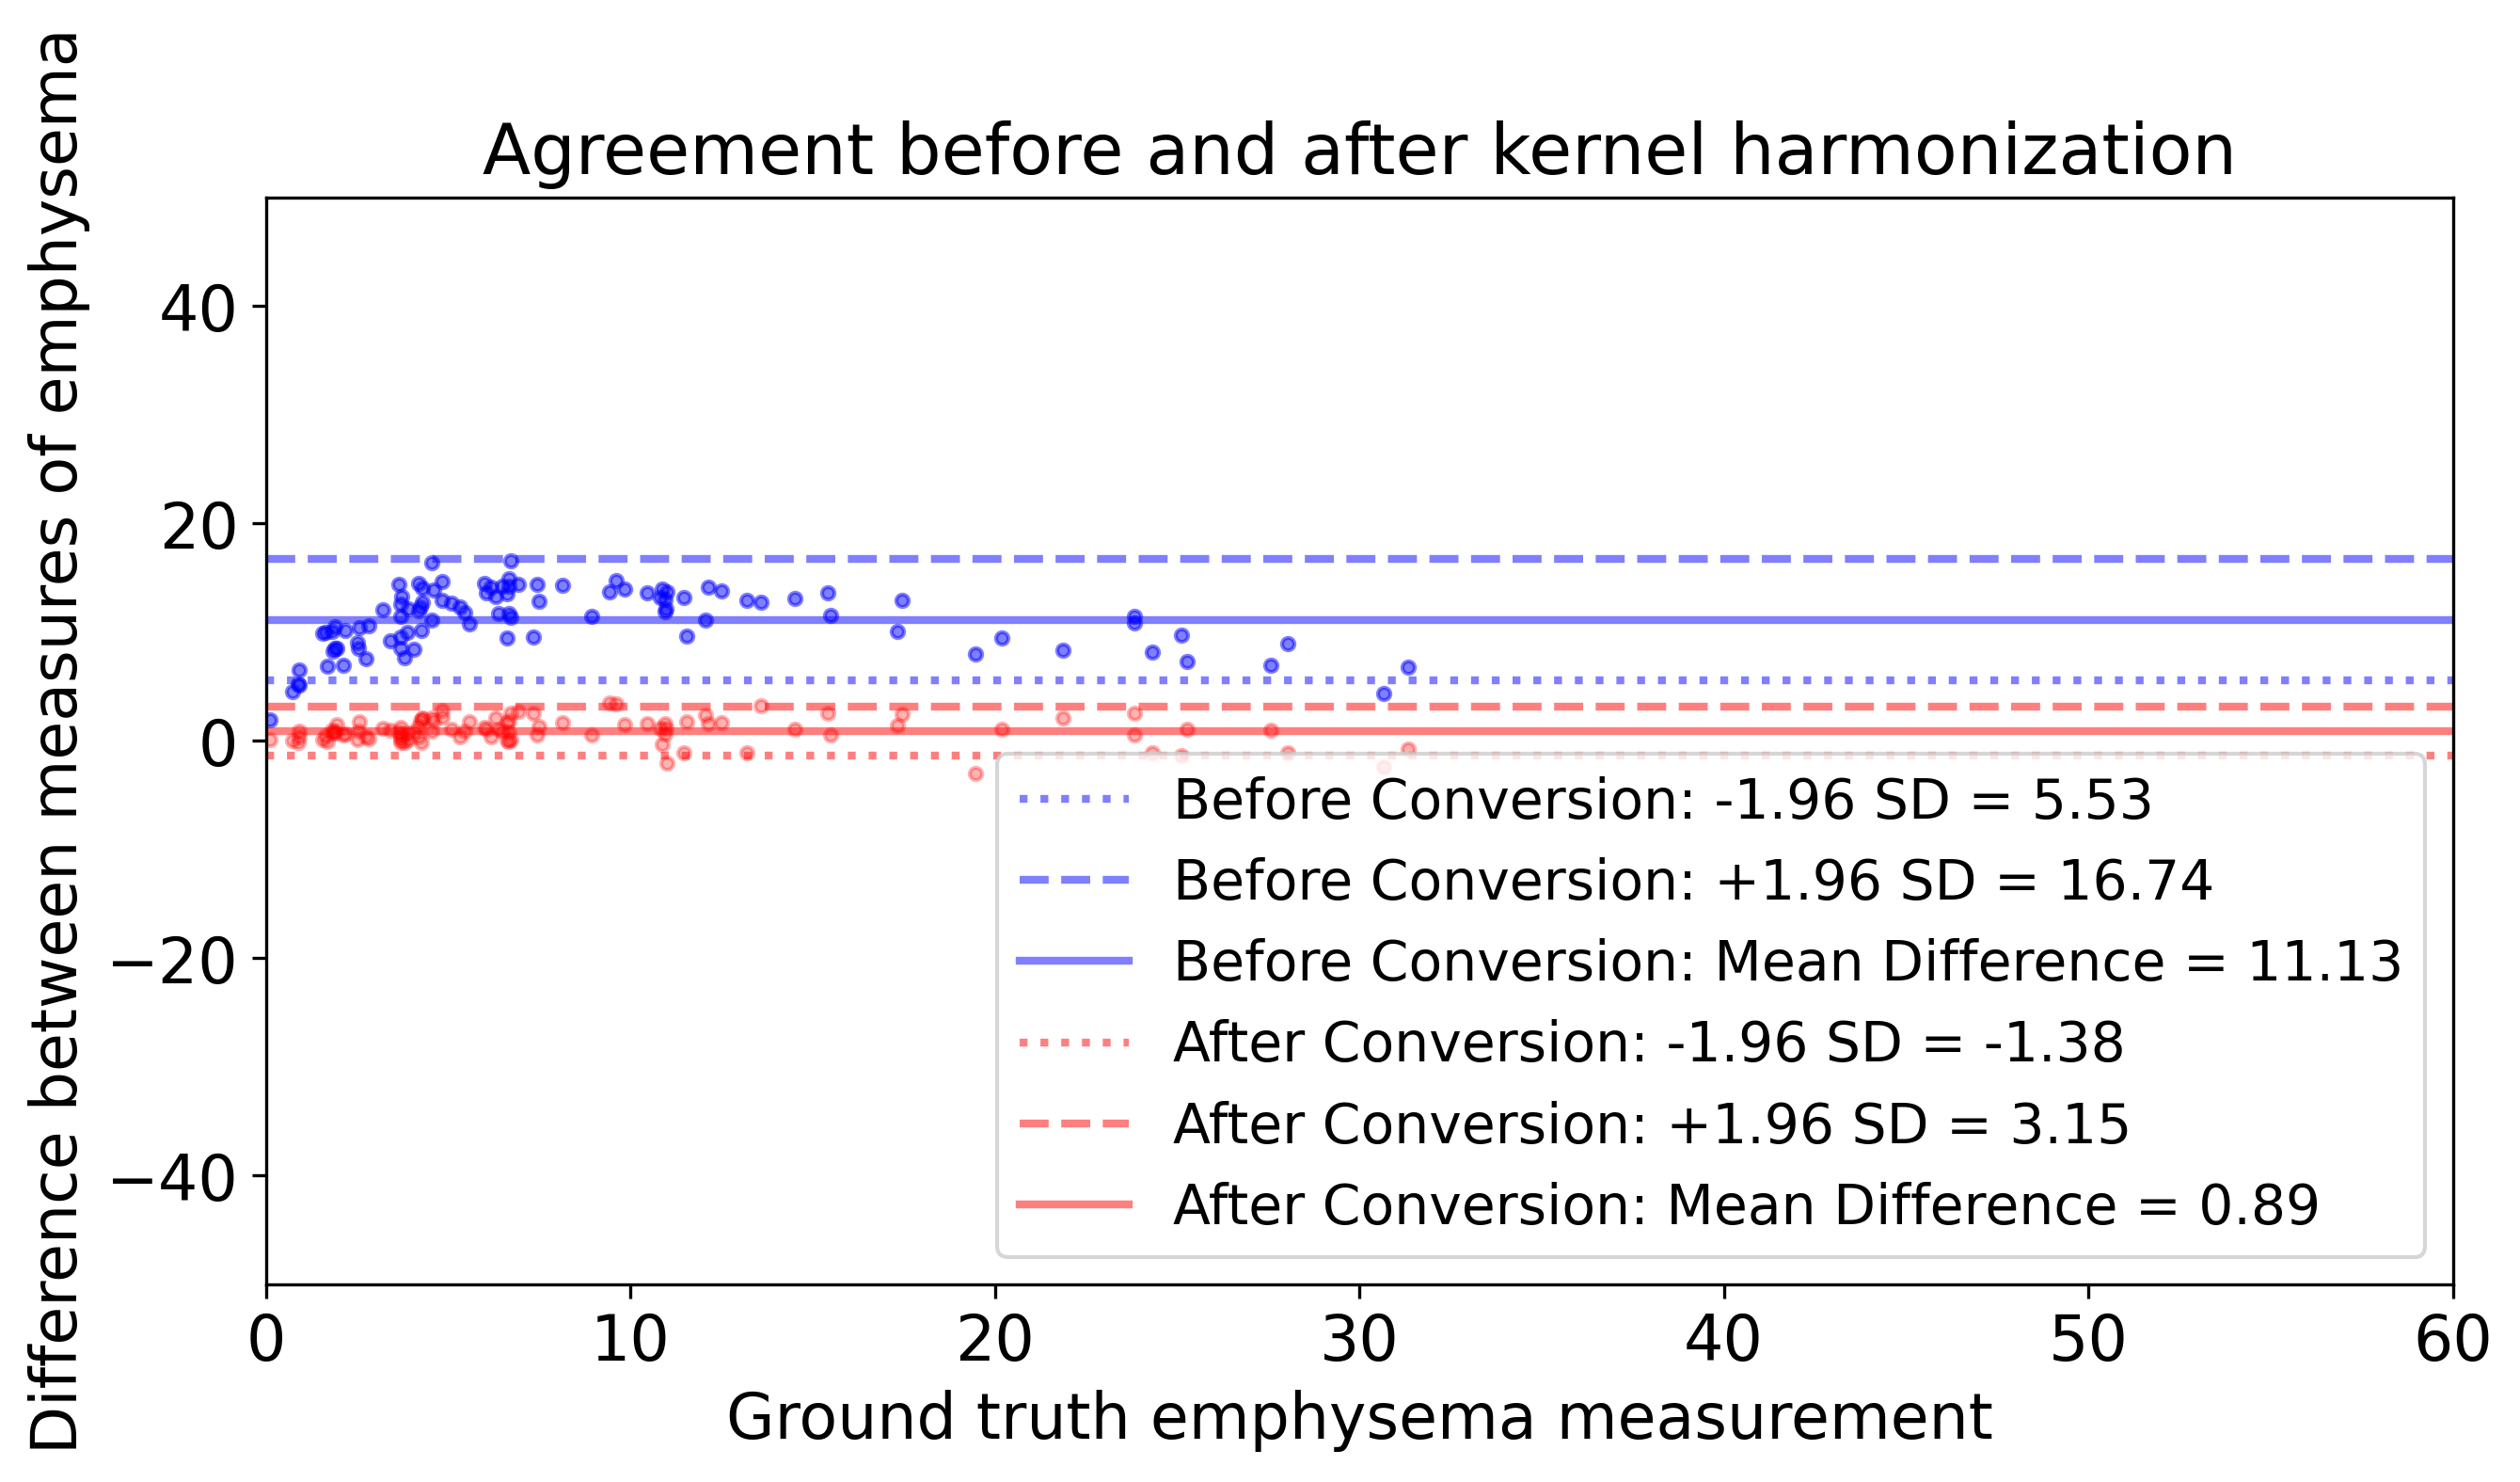

In [101]:
bland_altman_conversion_without_mean(b50f['emph_score'].values, b30f_b50f['emph_score'].values, b50ftob30f_best['emph_score'].values,
                                     x_plot_range = [0, 60], y_plot_range = [-50, 50])

In [18]:
#run stats test to see if things are significantly different
def run_stats_test_unpaired(data1, data2):
    # Perform the Mann-Whitney U test
    u_stat, u_p_value = mannwhitneyu(data1, data2, alternative='two-sided')
    print(f"Mann-Whitney U test statistic: {u_stat}, p-value: {u_p_value}")

def run_stats_test_paired(data1, data2):
    # Perform the Wilcoxon signed-rank test
    w_stat, w_p_value = wilcoxon(data1, data2, alternative='two-sided')
    print(f"Wilcoxon signed-rank test statistic: {w_stat}, p-value: {w_p_value}")

run_stats_test_unpaired(b80ftob30f_best['emph_score'].values, b30f_b50f['emph_score'].values)
run_stats_test_unpaired(b50ftob30f_best['emph_score'].values, b30f_b50f['emph_score'].values)
run_stats_test_unpaired(bonetob30f_best['emph_score'].values, b30f_b50f['emph_score'].values)
run_stats_test_unpaired(lungtob30f_best['emph_score'].values, b30f_b50f['emph_score'].values)
run_stats_test_unpaired(stdtob30f_best['emph_score'].values, b30f_b50f['emph_score'].values)

Mann-Whitney U test statistic: 2971.0, p-value: 0.0606885368364098
Mann-Whitney U test statistic: 5555.0, p-value: 0.17546244064801408
Mann-Whitney U test statistic: 5454.0, p-value: 0.26782862340758085
Mann-Whitney U test statistic: 5356.0, p-value: 0.38505241290747705
Mann-Whitney U test statistic: 5911.0, p-value: 0.026101009323488487


In [21]:
diff_b50f_b30f_before = b50f['emph_score'].values - b30f_b50f['emph_score'].values
diff_b50f_b30f_after = b50ftob30f_best['emph_score'].values - b30f_b50f['emph_score'].values

diff_b80f_b30f_before = b80f['emph_score'].values - b30f_b80f['emph_score'].values
diff_b80f_b30f_after = b80ftob30f_best['emph_score'].values - b30f_b80f['emph_score'].values

diff_bone_std_before = bone['emph_score'].values - std_bone['emph_score'].values
diff_bone_std_after = bonetostd_best['emph_score'].values - std_bone['emph_score'].values   

diff_lung_std_before = lung['emph_score'].values - std_lung['emph_score'].values
diff_lung_std_after = lungtostd_best['emph_score'].values - std_lung['emph_score'].values

run_stats_test_paired(diff_b50f_b30f_before, diff_b50f_b30f_after)
run_stats_test_paired(diff_b80f_b30f_before, diff_b80f_b30f_after)
run_stats_test_paired(diff_bone_std_before, diff_bone_std_after)
run_stats_test_paired(diff_lung_std_before, diff_lung_std_after)    

Wilcoxon signed-rank test statistic: 0.0, p-value: 3.896559845095909e-18
Wilcoxon signed-rank test statistic: 0.0, p-value: 7.556929455863566e-10
Wilcoxon signed-rank test statistic: 0.0, p-value: 3.896559845095909e-18
Wilcoxon signed-rank test statistic: 0.0, p-value: 3.896559845095909e-18


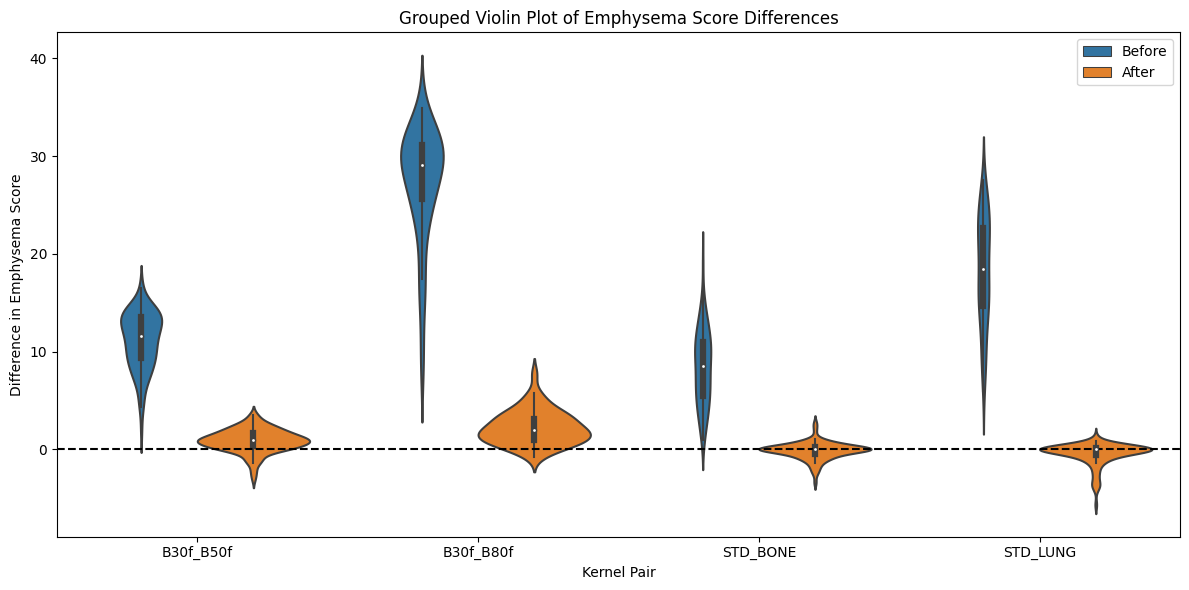

In [25]:
#Plot paired data differences in emphysema scores
kernel_labels = ['B30f_B50f', 'B30f_B80f', 'STD_BONE', 'STD_LUNG']
conditions = ['Before', 'After']

# Flatten and structure the data into long format
data = []
for kernel, before_vals, after_vals in zip(kernel_labels,
                                           [diff_b50f_b30f_before, diff_b80f_b30f_before, diff_bone_std_before, diff_lung_std_before],
                                           [diff_b50f_b30f_after, diff_b80f_b30f_after, diff_bone_std_after, diff_lung_std_after]):
    data.extend([(kernel, 'Before', val) for val in before_vals])
    data.extend([(kernel, 'After', val) for val in after_vals])

df = pd.DataFrame(data, columns=['Kernel', 'Condition', 'Difference'])

# Create grouped violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Kernel', y='Difference', hue='Condition', dodge=True)

# Add horizontal line at y=0
plt.axhline(0, color='black', linestyle='--')

# Axis labels and title
plt.title('Grouped Violin Plot of Emphysema Score Differences')
plt.ylabel('Difference in Emphysema Score')
plt.xlabel('Kernel Pair')
plt.legend()

plt.tight_layout()
plt.show()